# 📈 Support Vector Regressor (SVR)

## 1️⃣ ¿Qué es Support Vector Regression?

**Support Vector Regression (SVR)** es un algoritmo de **regresión supervisada** basado en los **Support Vector Machines (SVM)**.

A diferencia de la regresión lineal tradicional, SVR:
- Busca una **función lo más plana posible**
- Tolera un **margen de error** definido por un parámetro ε (epsilon)
- Penaliza solo los errores que **superan ese margen**

🔑 Idea clave:
> No intenta minimizar el error total, sino **controlar la complejidad del modelo** y los errores grandes.

---

## 2️⃣ Intuición del modelo

SVR intenta encontrar una función:

$$
f(x) = w \cdot x + b
$$

tal que:
- La mayoría de los puntos queden dentro de un **tubo de ancho 2ε**
- Los puntos fuera del tubo son penalizados

🎯 Objetivo:
- Mantener el modelo **simple**
- Permitir pequeños errores
- Castigar errores grandes

---

## 3️⃣ Parámetros clave del SVR

| Parámetro | Descripción |
|---------|------------|
| `kernel` | Tipo de función (lineal, polinómica, RBF) |
| `C` | Penalización por error (regularización) |
| `epsilon` | Tamaño del margen de tolerancia |
| `gamma` | Influencia de un solo punto |
| `degree` | Grado del polinomio (solo kernel `poly`) |
| `coef0` | Término independiente en kernels `poly` y `sigmoid` |

---

## 4️⃣ Kernels más usados

| Kernel | Uso recomendado |
|------|----------------|
| `linear` | Relaciones lineales |
| `rbf` | Relaciones no lineales (más común) |
| `poly` | Relaciones polinómicas |
| `sigmoid` | Similar a redes neuronales |

---



# 📌 EJEMPLO SIMPLE: SVR para predecir una secuencia numérica


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# 1️⃣ Generar una secuencia numérica simple

In [2]:
X = np.arange(1, 21).reshape(-1, 1)   # [1, 2, 3, ..., 20]
y = 2 * X.ravel() + np.random.randn(20)

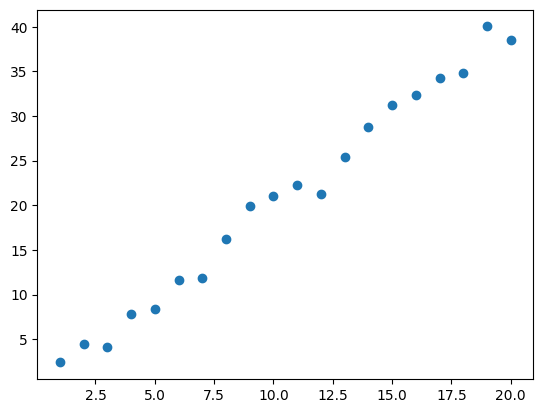

In [3]:
plt.scatter(X,y)

# 2️⃣ Escalar los datos (MUY IMPORTANTE para SVR)

In [4]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

# 3️⃣ Crear y entrenar el modelo SVR

In [5]:
svr = SVR(
    kernel="linear",  # Relación lineal
    C=10,
    epsilon=0.1
)

svr.fit(X_scaled, y_scaled)

SVR(C=10, kernel='linear')

# 4️⃣ Predecir nuevos valores de la secuencia

In [6]:
# Valores futuros
X_future = np.array([[21], [22], [23]])
X_future_scaled = scaler_X.transform(X_future)

y_future_scaled = svr.predict(X_future_scaled)
y_future = scaler_y.inverse_transform(y_future_scaled.reshape(-1, 1))

print("Predicciones:")
for x, y_pred in zip(X_future.ravel(), y_future.ravel()):
    print(f"x = {x} → y ≈ {y_pred:.2f}")

Predicciones:
x = 21 → y ≈ 42.14
x = 22 → y ≈ 44.19
x = 23 → y ≈ 46.23


# 5️⃣ Visualizar resultados

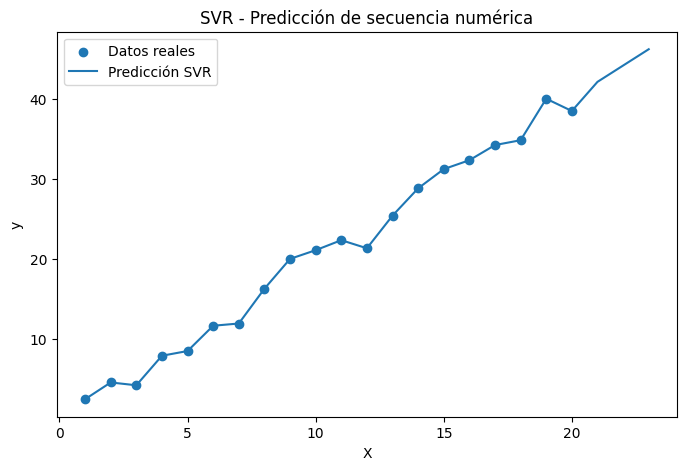

In [7]:
plt.figure(figsize=(8, 5))

# Asegurar 1D en todo
X_plot = X.ravel()
y_plot = y.ravel()

X_future_plot = X_future.ravel()
y_future_plot = y_future.ravel()  # y_future viene (m,1), lo volvemos 1D

# Datos reales
plt.scatter(X_plot, y_plot, label="Datos reales")

# Predicción (línea uniendo datos + futuros)
plt.plot(
    np.concatenate([X_plot, X_future_plot]),
    np.concatenate([y_plot, y_future_plot]),
    label="Predicción SVR"
)

plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("SVR - Predicción de secuencia numérica")
plt.show()

